## Long Term Memory with SQLite

In [1]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

In [2]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, RemoveMessage
from typing import Literal
from langgraph.checkpoint.memory import InMemorySaver
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

## Define the State

In [3]:
class State(MessagesState):
    summary: str

In [4]:
chat = ChatOpenAI(model_name = "gpt-4o",
                  seed = 365,
                  temperature = 0,
                  max_completion_tokens = 100)

In [5]:
def ask_question(state: State) -> State:

     print(f'\n-------Entering ask_question:')

     question = "What is your question"
     print(question)

     return State(messages = [AIMessage(question), HumanMessage(input())])

In [6]:
def chatbot(state: State) -> State:

    print(f'\n-------Entering Chatbot:')
    for i in state["messages"]:
         i.pretty_print()

    system_message = f'''
    Here's a quick summary of what was discussed so far
    {state.get("summary", "")}

    Keep this in mind as you answer the next question.
    '''
    
    response = chat.invoke([SystemMessage(system_message)] + state["messages"])
    response.pretty_print()

    return State(messages = [response])

In [7]:
def summarize_messages(state: State) -> State:
    print(f'\n------ENTERING trim messages')

    new_conversation = ""
    for i in state["messages"]:
        new_conversation+= f"{i.type}: {i.content}\n\n"

    summary_instructions = f'''
    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result reflects
    the most recent context and developments

    previous_summary:
    {state.get("summary", "")}

    new_conversation:
    {new_conversation}
    '''
    print(summary_instructions)
    summary = chat.invoke([HumanMessage(summary_instructions)])

    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]]
    return State(messages = remove_messages, summary = summary.content)

In [8]:
def routing_function(state: State) -> Literal["summarize_messages", "__end__"]:

    if state["messages"][-1].content == "yes":
        return "summarize_messages"
    else:
        return "__end__"

In [9]:
graph = StateGraph(State)

In [10]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("summarize_messages", summarize_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "summarize_messages")
graph.add_edge("summarize_messages", END)

In [11]:
db_path = "C:/Users/HP-PC/LangGraph_DB/langgraph.db"
con = sqlite3.connect(database=db_path, check_same_thread=False)

In [12]:
checkpointer = SqliteSaver(con)

In [13]:
graph_compiled = graph.compile(checkpointer)

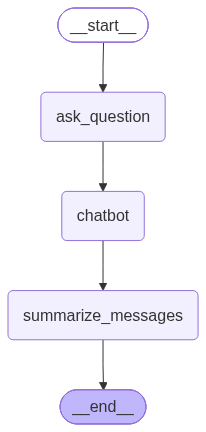

In [14]:
graph_compiled

In [15]:
config1 = {"configurable": {"thread_id": "1"}}

In [16]:
graph_compiled.invoke(State(), config1)


-------Entering ask_question:
What is your question


 Where was he born?



-------Entering Chatbot:
================================== Ai Message ==================================

What is your question
================================ Human Message =================================

Where was he born?
================================== Ai Message ==================================

Guido van Rossum was born in The Hague, Netherlands.

------ENTERING trim messages

    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result reflects
    the most recent context and developments

    previous_summary:
    previous_summary: The conversation began with the AI asking the human if they had any questions.

updated_summary: The conversation started with the AI asking the human if they had any questions. The human then inquired about the creator of the Python programming language, to which the AI responded that Guido van Rossum is the creator, having started work

{'messages': [],
 'summary': "The conversation started with the AI asking the human if they had any questions. The human then inquired about the creator of the Python programming language, to which the AI responded that Guido van Rossum is the creator, having started working on Python in the late 1980s and releasing it in 1991. The human further asked about Guido van Rossum's birthplace, and the AI informed them that he was born in The Hague, Netherlands."}

In [17]:
graph_state = [i for i in graph_compiled.get_state_history(config1)]

In [18]:
graph_state

[StateSnapshot(values={'messages': [], 'summary': "The conversation started with the AI asking the human if they had any questions. The human then inquired about the creator of the Python programming language, to which the AI responded that Guido van Rossum is the creator, having started working on Python in the late 1980s and releasing it in 1991. The human further asked about Guido van Rossum's birthplace, and the AI informed them that he was born in The Hague, Netherlands."}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1873cb-3fa2-6d48-8008-a95d2db59f8a'}}, metadata={'source': 'loop', 'step': 8, 'parents': {}}, created_at='2026-07-24T08:50:21.250080+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1873cb-1bdc-60c3-8007-1f491aa24e38'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'messages': [AIMessage(content='What is your question', additional_kwargs={}, response_metadata={}, id=

In [19]:
for i in graph_state[::-1]:
    print(f'''
Messages: {i.values["messages"]}
Summary: {i.values.get("summary", "")}
Next: {i.next}
Step: {i.metadata["step"]}''')


Messages: []
Summary: 
Next: ('__start__',)
Step: -1

Messages: []
Summary: 
Next: ('ask_question',)
Step: 0

Messages: [AIMessage(content='What is your question', additional_kwargs={}, response_metadata={}, id='0ebfafc3-e520-4099-a993-d5c5ac17f94e', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Who is the creator of the python language?', additional_kwargs={}, response_metadata={}, id='b8576f12-77df-4beb-8557-cfd76f8928fe')]
Summary: 
Next: ('chatbot',)
Step: 1

Messages: [AIMessage(content='What is your question', additional_kwargs={}, response_metadata={}, id='0ebfafc3-e520-4099-a993-d5c5ac17f94e', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Who is the creator of the python language?', additional_kwargs={}, response_metadata={}, id='b8576f12-77df-4beb-8557-cfd76f8928fe'), AIMessage(content='The Python programming language was created by Guido van Rossum. He started working on Python in the late 1980s, and it was first released in 1991.', additional_k